# Ligand-Receptor Experiment

Two-population simulation with fast ligands, slow receptors, type-specific spot widths, and simple binding/unbinding dynamics.

In [1]:
%cd ..
%load_ext autoreload
%autoreload 2
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


## I. Simulation of the receptors and ligands interactions

In [2]:
simulation_config = {
    "n_ligands": 10,
    "n_receptors": 5,
    "nframes": 50,
    "nposframe": 5,
    "dt": 1.0,
    "ligand_D": [(3.0, 0.65), (6.0, 0.35)],
    "receptor_D": [(0.0, 0.75), (0.05, 0.25)],
    "frame_size": (128, 128),
    "boundary_margin": 10,
    "binding_radius": 6.0,
    "kon": 2.0,
    "koff": 0.05,
    "allow_multiple_ligands_per_receptor": False,
    "bound_position_noise": 0.15,
    "ligand_intensity_mean": 750,
    "ligand_intensity_std": 100,
    "receptor_intensity_mean": 750,
    "receptor_intensity_std": 150,
    "ligand_sigma_mean": 0.75,
    "ligand_sigma_std": 0.08,
    "receptor_sigma_mean": 1.35,
    "receptor_sigma_std": 0.12,
}

image_config = {
    "particle_intensity": [700, 300],
    "particle_sigma": [1.0, 0.2],
    "particle_type_props": {
        "ligand": {
            "particle_intensity": [750, 100],
            "particle_sigma": [0.75, 0.08],
        },
        "receptor": {
            "particle_intensity": [750, 150],
            "particle_sigma": [1.35, 0.12],
        },
    },
    "use_trajectory_sigma": True,
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = LigandReceptorSimulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR
trajectories_GT = sim.trajectories_GT
ligands_GT = sim.get_ligands()
receptors_GT = sim.get_receptors()
binding_events = sim.binding_events
video_ligand_receptor = sim.video

In [3]:
print(f"Ligands: {len(ligands_GT)}")
print(f"Receptors: {len(receptors_GT)}")
print(f"Binding events: {len(binding_events)}")

if binding_events:
    durations = [event["end_subframe"] - event["start_subframe"] + 1 for event in binding_events]
    print(f"Mean bound duration: {np.mean(durations):.2f} subframes")
    print(binding_events[:5])

Ligands: 10
Receptors: 5
Binding events: 0


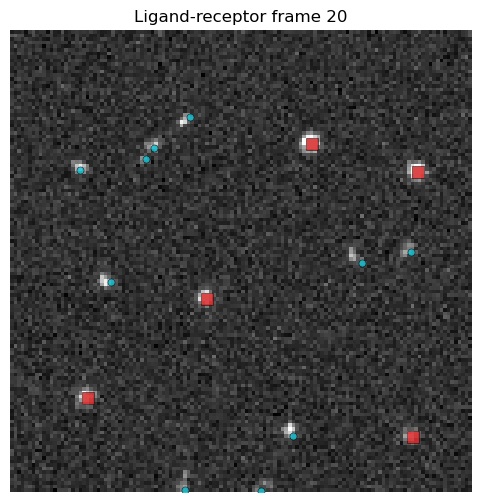

In [4]:
def plot_ligand_receptor_frame(sim, frame_id=0, show_ids=False):
    fig, ax = plt.subplots(figsize=(6, 6))
    vmax = np.percentile(sim.frames, 99.8)
    ax.imshow(sim.frames[frame_id], cmap="gray", vmin=0, vmax=vmax)

    for traj in sim.trajectories_GT:
        pos = traj.get_position_at_frame(frame_id)
        if pos is None:
            continue

        row, col = pos
        is_receptor = traj.particle_type == "receptor"
        is_bound = traj.get_state_at_frame(frame_id) == "bound"

        ax.scatter(
            col,
            row,
            s=75 if is_receptor else 26,
            c="tab:red" if is_receptor else "tab:cyan",
            marker="s" if is_receptor else "o",
            edgecolors="yellow" if is_bound else "black",
            linewidths=1.2 if is_bound else 0.4,
            alpha=0.85,
        )

        if show_ids:
            ax.text(col + 1, row + 1, str(traj.id), color="white", fontsize=8)

    ax.set_title(f"Ligand-receptor frame {frame_id}")
    ax.axis("off")
    plt.show()


plot_ligand_receptor_frame(sim, frame_id=20, show_ids=False)

In [5]:
sim.animate(interval=100, vmax=np.percentile(frames, 99.8))

## II. Application of the masked tracking pipeline

In [6]:
# 1) Conservative pass: find only long, nearly static receptor tracks.
static_results = sim.track(
    mode="localization",
    detection_threshold=400,
    max_distance=2,
    min_length=25,
    max_gap=0,
    cost_func_peak2peak=None,
    cost_func_traj2traj=None
)
static_trajs_loc_sep = static_results[0]
print(f"Found {len(static_trajs_loc_sep)} static receptor candidates.")

# 2) Sensitive pass: extract weaker/smaller ligand peaks.
peaks_for_tracking_sep = extract_peaks(
    frames,
    mode="localization",
    detection_threshold=300,
    r_squared_threshold=0.35,
    verbose_loc=False,
    visualization_loc=False,
)

n_extracted_peaks = sum(len(peaks) for peaks in peaks_for_tracking_sep)
print(f"Extracted {n_extracted_peaks} localized peaks with the ligand-sensitive settings.")

# Remove static receptor peaks without using too large a radius around bound ligands.
mobile_peaks_for_tracking_sep = remove_static_peaks(
    peaks_for_tracking_sep,
    static_trajs_loc_sep,
    tolerance=3.0,
    verbose=True,
)


# 3) Ligand-friendly tracking: keep short fragments, reconnect missed detections, then stitch fragments.
trajs_loc_sep, cost_peak2peak_sep, assignment_output_sep, cost_traj2traj_sep = track_from_peaks(
    mobile_peaks_for_tracking_sep,
    trajectories_GT,
    max_distance=12,
    min_length=2,
    max_gap=2,
    stitch_fragments=True,
    stitch_max_gap=4,
    stitch_base_distance=10,
    stitch_kwargs={"max_link_cost": 2.0},
    verbose_stitching=True,
    algo_peak2peak="hungarian",
    cost_func_peak2peak=None,
    algo_traj2traj="hungarian",
    cost_func_traj2traj=None,
    verbose_assignment=False,
)
print(f"Found {len(trajs_loc_sep)} mobile trajectories.")

# Add receptor tracks back for full receptor/ligand visualization and evaluation.
trajs_loc_sep += static_trajs_loc_sep

[Frame 39] Poor fit for peak at (111, 76): R-squared = 0.329 (below threshold of 0.5).
[Frame 46] No computed R-squared for peak at (79, 1).
Found 5 static receptor candidates.
[Frame 1] Poor fit for peak at (34, 14): R-squared = 0.274 (below threshold of 0.35).
[Frame 16] Poor fit for peak at (101, 85): R-squared = 0.286 (below threshold of 0.35).
[Frame 20] No computed R-squared for peak at (126, 48).
[Frame 23] No computed R-squared for peak at (126, 49).
[Frame 29] No computed R-squared for peak at (120, 53).
[Frame 39] Poor fit for peak at (111, 76): R-squared = 0.329 (below threshold of 0.35).
[Frame 42] Poor fit for peak at (19, 43): R-squared = 0.120 (below threshold of 0.35).
[Frame 43] No computed R-squared for peak at (126, 69).
[Frame 46] No computed R-squared for peak at (79, 1).
[Frame 48] No computed R-squared for peak at (34, 1).
Extracted 702 localized peaks with the ligand-sensitive settings.
Removed 50 peaks from static trajectory 0 (length 50, frames 0–49)
Removed 5

In [7]:
trajs_loc_sep, min_cost, assignment = assign_trajectories(trajs_loc_sep, trajectories_GT, cost_function = None, verbose=True)

Computing assignment using algorithm: hungarian
0 -> -1
1 -> 13
2 -> 7
3 -> -1
4 -> -1
5 -> -1
6 -> 9
7 -> -1
8 -> 8
9 -> -1
10 -> -1
11 -> 11
12 -> -1
13 -> -1
14 -> -1
15 -> -1
16 -> -1
17 -> -1
18 -> -1
19 -> 5
20 -> 10
21 -> -1
22 -> -1
23 -> -1
24 -> 12
25 -> -1
26 -> 14
27 -> -1
28 -> -1
29 -> -1
30 -> -1
31 -> 6
32 -> 0
33 -> 3
34 -> 1
35 -> 4
36 -> 2
Trajectory ID: -1, Frames: 0->9, Number of positions: 7, Relabelled: No
Trajectory ID: 13, Frames: 0->17, Number of positions: 18, Relabelled: Yes
Trajectory ID: 7, Frames: 0->19, Number of positions: 18, Relabelled: Yes
Trajectory ID: -1, Frames: 0->5, Number of positions: 4, Relabelled: No
Trajectory ID: -1, Frames: 0->3, Number of positions: 4, Relabelled: No
Trajectory ID: -1, Frames: 0->40, Number of positions: 40, Relabelled: No
Trajectory ID: 9, Frames: 0->17, Number of positions: 17, Relabelled: Yes
Trajectory ID: -1, Frames: 0->28, Number of positions: 28, Relabelled: No
Trajectory ID: 8, Frames: 0->49, Number of positions

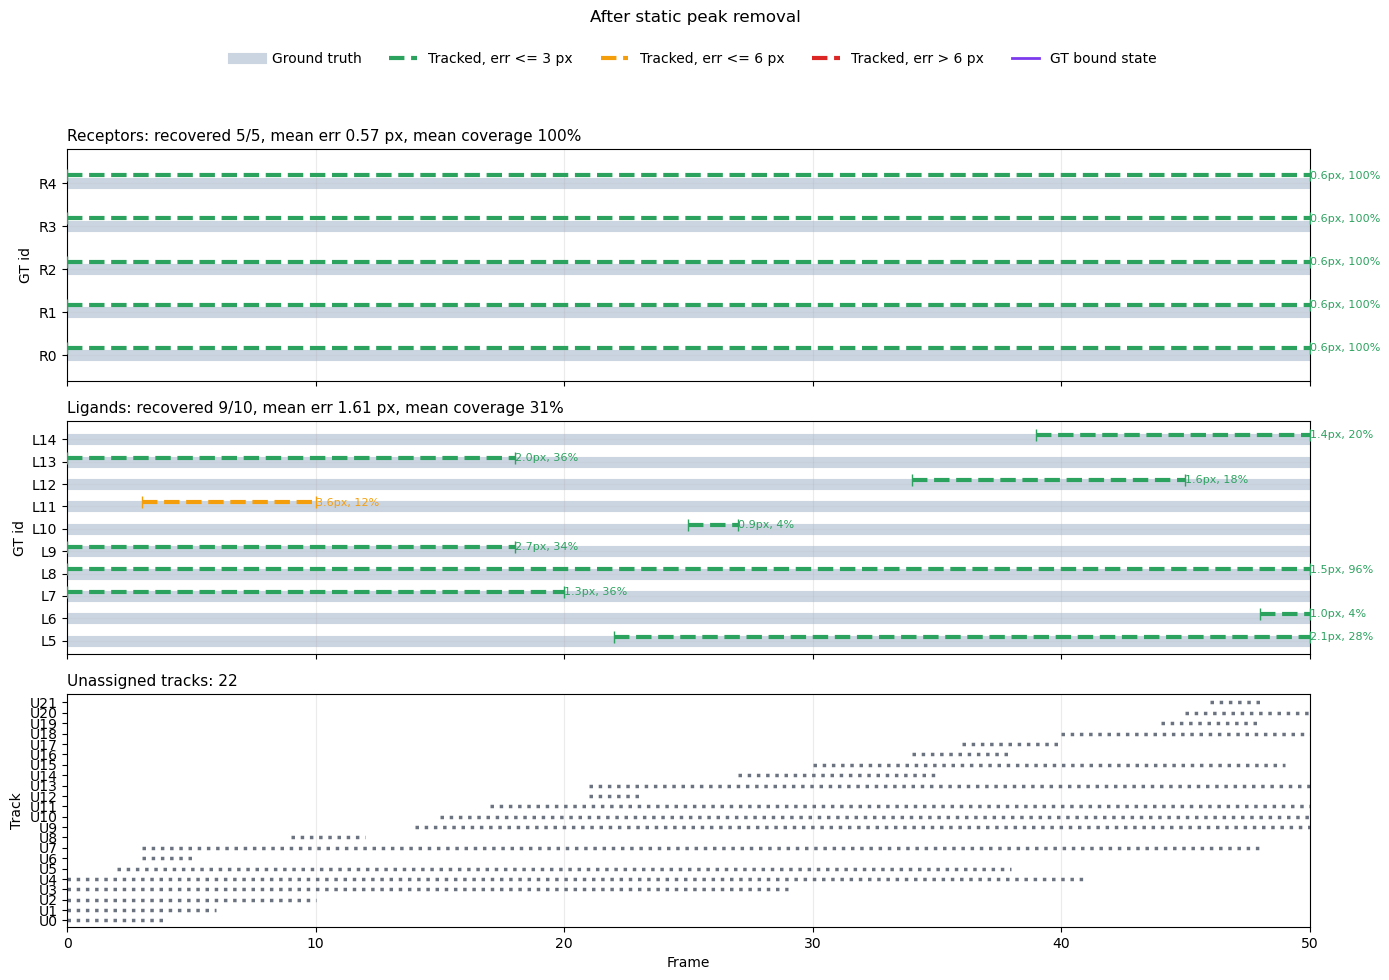

In [8]:
linear_trajectories_visualizer(
    trajs_loc_sep,
    trajectories_GT,
    quality_tolerance=3.0,
    show_labels=True,
    title="After static peak removal"
)

In [9]:
# the the true GT immobile particles (receptors)
print("True immobile particles (receptors):")
for traj in trajectories_GT:
    if traj.particle_type == "receptor":
        print(f"Receptor ID {traj.id} at position {traj.get_position_at_frame(0)}")

True immobile particles (receptors):
Receptor ID 0 at position (38.944654284368255, 112.67714509227095)
Receptor ID 1 at position (101.49121296809214, 20.992507043003606)
Receptor ID 2 at position (112.38710136564097, 111.1109225943185)
Receptor ID 3 at position (31.06118803447687, 83.05853722044712)
Receptor ID 4 at position (74.03249917443222, 54.01464735150253)


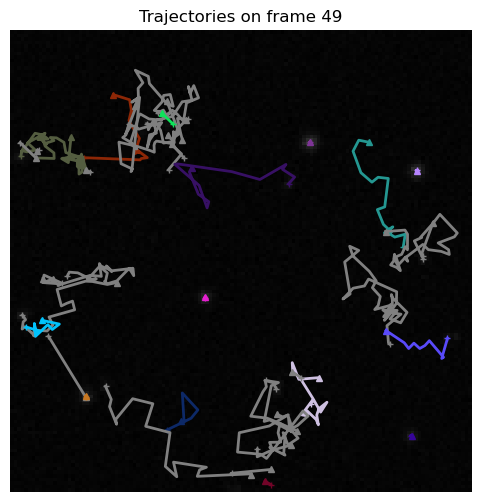

In [10]:
show_trajectories(frames,trajs_loc_sep, frame_id=simulation_config["nframes"]-1)